Dear Participant,

Parkinson’s Disease (PD) is a degenerative neurological disorder marked by decreased dopamine levels in the brain. It manifests itself through a deterioration of movement, including the presence of tremors and stiffness. There is commonly a marked effect on speech, including dysarthria (difficulty articulating sounds), hypophonia (lowered volume), and monotone (reduced pitch range). Additionally, cognitive impairments and changes in mood can occur, and risk of dementia is increased.

Traditional diagnosis of Parkinson’s Disease involves a clinician taking a neurological history of the patient and observing motor skills in various situations. Since there is no definitive laboratory test to diagnose PD, diagnosis is often difficult, particularly in the early stages when motor effects are not yet severe. Monitoring progression of the disease over time requires repeated clinic visits by the patient. An effective screening process, particularly one that doesn’t require a clinic visit, would be beneficial. Since PD patients exhibit characteristic vocal features, voice recordings are a useful and non-invasive tool for diagnosis. If machine learning algorithms could be applied to a voice recording dataset to accurately diagnosis PD, this would be an effective screening step prior to an appointment with a clinician.

Use the provided dataset in order to do your analysis.

## Attribute Information:

### Matrix column entries (attributes):

#### name - ASCII subject name and recording number
#### MDVP:Fo(Hz) - Average vocal fundamental frequency
#### MDVP:Fhi(Hz) - Maximum vocal fundamental frequency
#### MDVP:Flo(Hz) - Minimum vocal fundamental frequency
#### MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP - Several 
#### measures of variation in fundamental frequency
#### MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA - Several measures of variation in amplitude
#### NHR,HNR - Two measures of ratio of noise to tonal components in the voice
#### status - Health status of the subject (one) - Parkinson's, (zero) - healthy
#### RPDE,D2 - Two nonlinear dynamical complexity measures
#### DFA - Signal fractal scaling exponent
#### spread1,spread2,PPE - Three nonlinear measures of fundamental frequency variation

In [1]:
# Import required library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### Q1. Load the dataset 

In [2]:
df1 = pd.read_csv("parkinsons.csv")

In [3]:
df1.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,Yes,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,Yes,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,Yes,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,Yes,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,Yes,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [4]:
df1.dtypes

name                 object
MDVP:Fo(Hz)         float64
MDVP:Fhi(Hz)        float64
MDVP:Flo(Hz)        float64
MDVP:Jitter(%)      float64
MDVP:Jitter(Abs)    float64
MDVP:RAP            float64
MDVP:PPQ            float64
Jitter:DDP          float64
MDVP:Shimmer        float64
MDVP:Shimmer(dB)    float64
Shimmer:APQ3        float64
Shimmer:APQ5        float64
MDVP:APQ            float64
Shimmer:DDA         float64
NHR                 float64
HNR                 float64
status               object
RPDE                float64
DFA                 float64
spread1             float64
spread2             float64
D2                  float64
PPE                 float64
dtype: object

### Q2. Use the .describe() method on the dataset and state any insights you may come across.

In [5]:
# Descriptive Statistics
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


#### Observations:
##### We can identify variables that are likely to have high outliers by looking for a substantial difference between the 75th percentile and the maximum value, especially when considered in the context of the overall distribution (mean, standard deviation)
###### As per the above decriptive statics table, below variables appear to have high outliers based on the substantial difference between their 75th percentile and maximum values.
###### - related to frequency (MDVP:Fhi(Hz)[Highest Standard Deviation of 91], MDVP:Flo(Hz)[2nd Highest Standard Deviation of 43], MDVP:Fo(Hz) [3rd Highest Standard Deviation of 41])
###### - related to frequency jitter (%, MDVP:Jitter(Abs), MDVP:RAP, MDVP:PPQ , Jitter:DDP)
###### - related to frequency shimmer (MDVP:Shimmer, MDVP:Shimmer(dB),Shimmer:APQ3, Shimmer:APQ5)
###### - related to frequency noise (NHR), and pitch period entropy (PPE) 

### Q3. Check for class imbalance. Do people with Parkinson's have greater representation in the dataset?

Class distribution:
 status
Yes    147
No      48
Name: count, dtype: int64
Class distribution (%):
 status
Yes    75.384615
No     24.615385
Name: count, dtype: float64


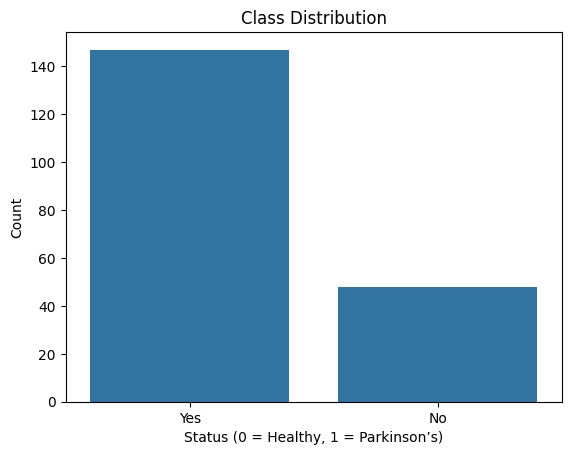

In [6]:
class_counts = df1['status'].value_counts()
print("Class distribution:\n", class_counts)

# Check class distribution percentage
print("Class distribution (%):\n", class_counts / len(df1) * 100)

# Visualize class imbalance
sns.countplot(x='status', data=df1)
plt.title('Class Distribution')
plt.xlabel('Status (0 = Healthy, 1 = Parkinson’s)')
plt.ylabel('Count')
plt.show()

#### Observations: 
##### As per the above bar plot, people with Parkinson's have greater representation in the given dataset. 

### Q4. Check for missing vaues and take necessary measures by dropping observation or imputing them.

In [7]:
df1.isnull().sum()

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

##### Observations: There are no missing values.

### Q5. Plot the distribution of all the features. State any observations you can make based on the distribution plots.

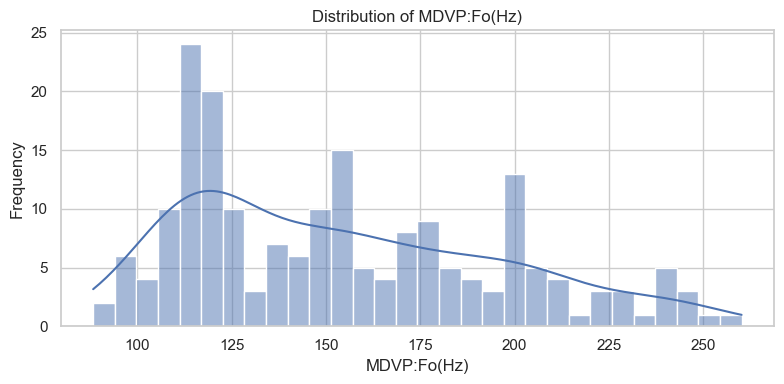

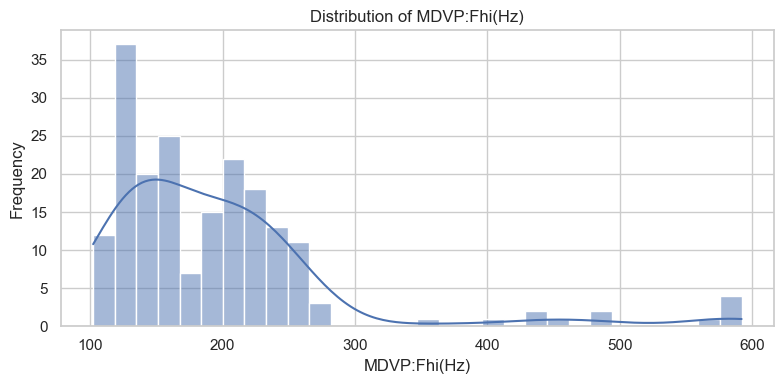

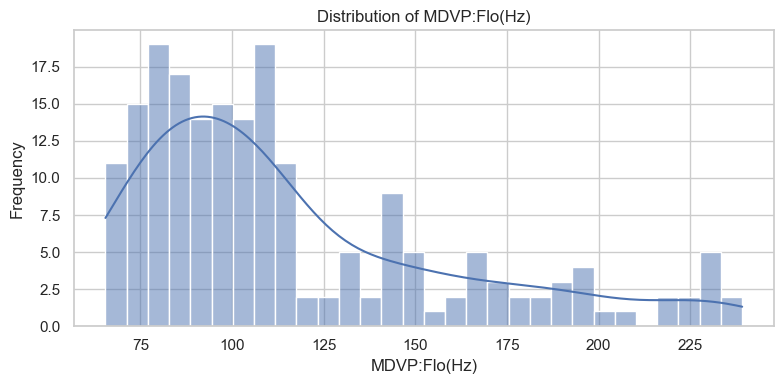

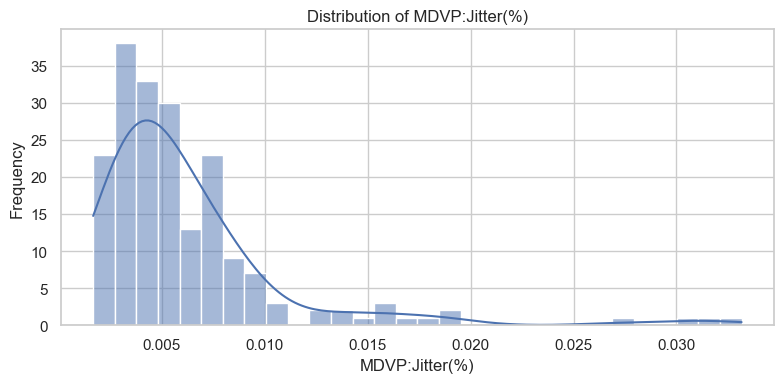

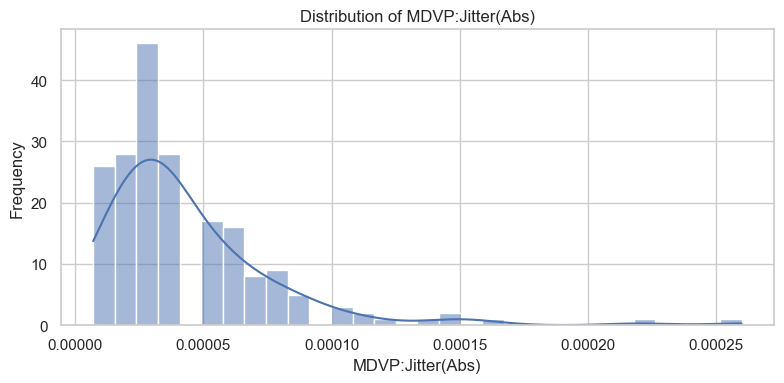

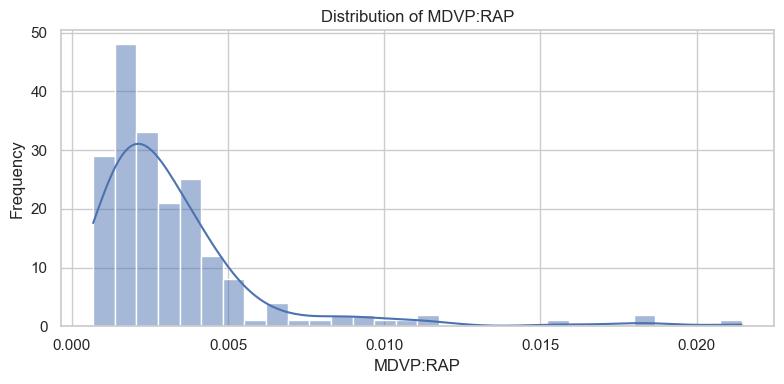

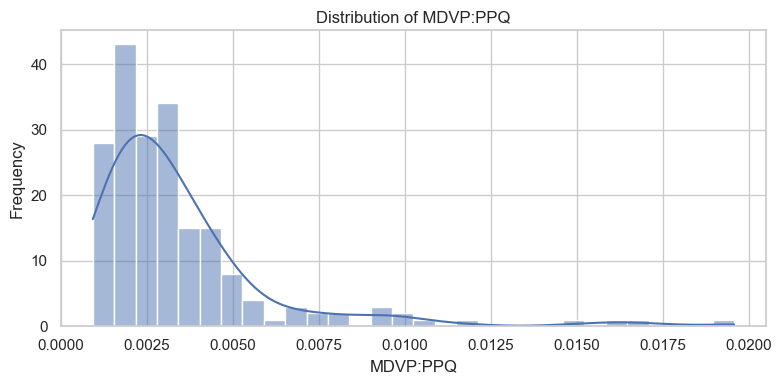

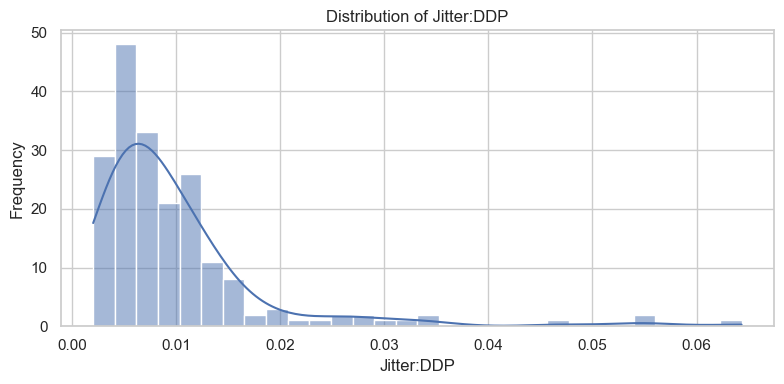

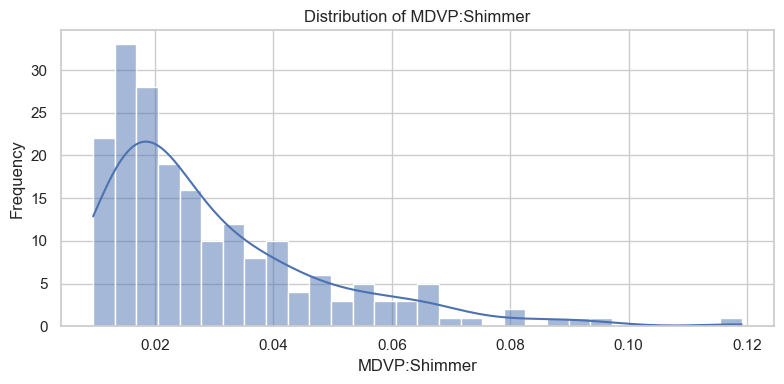

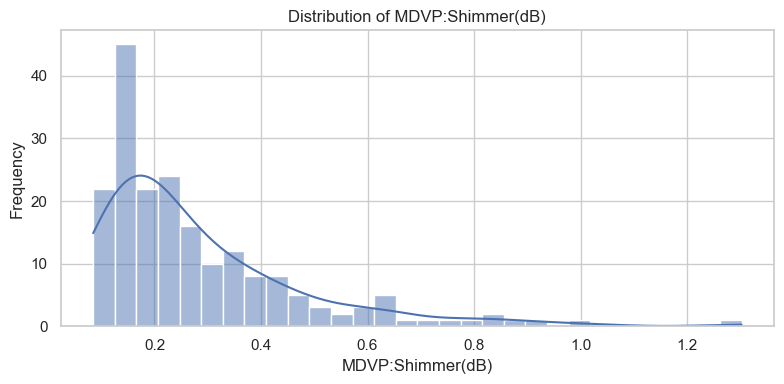

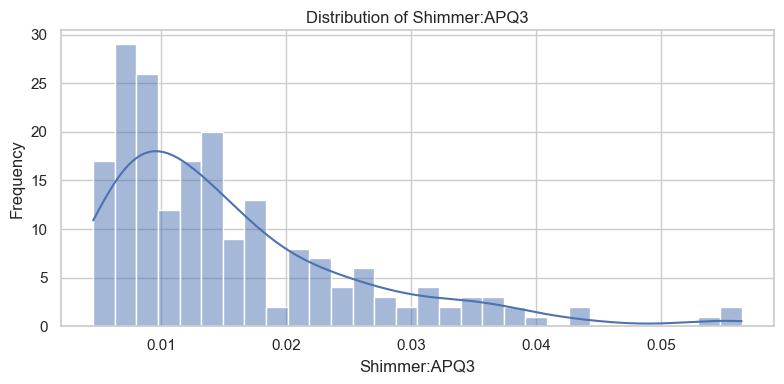

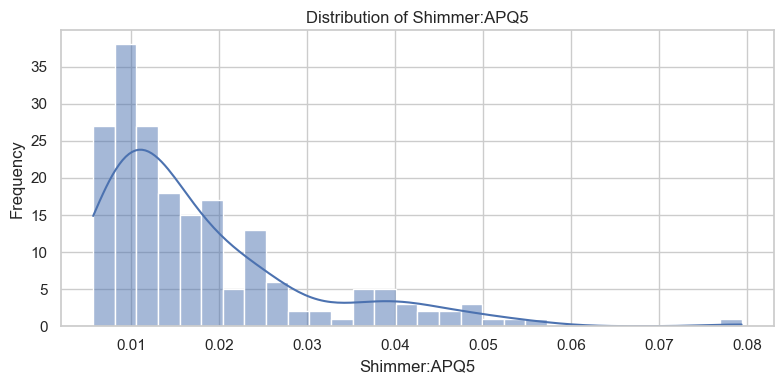

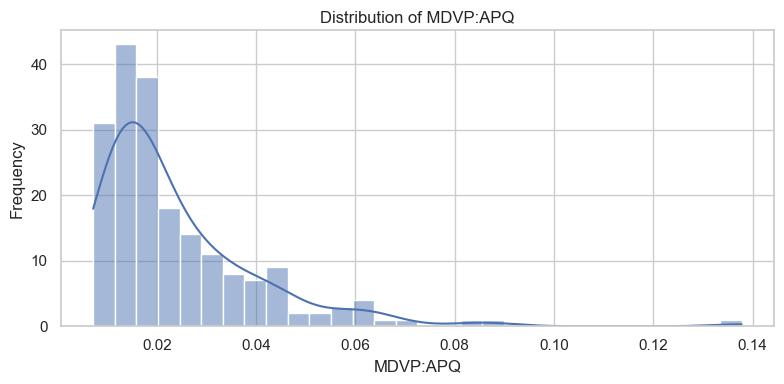

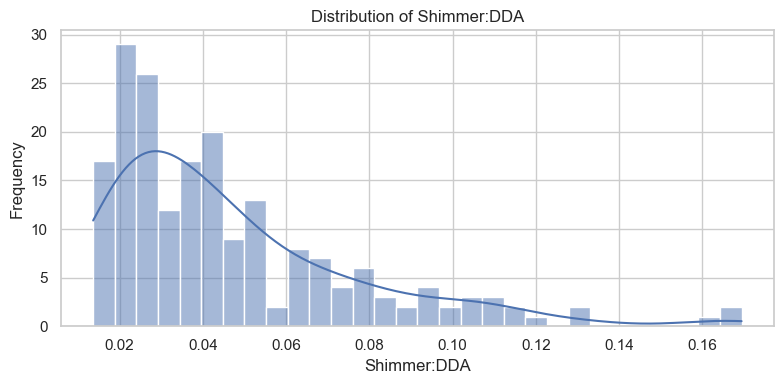

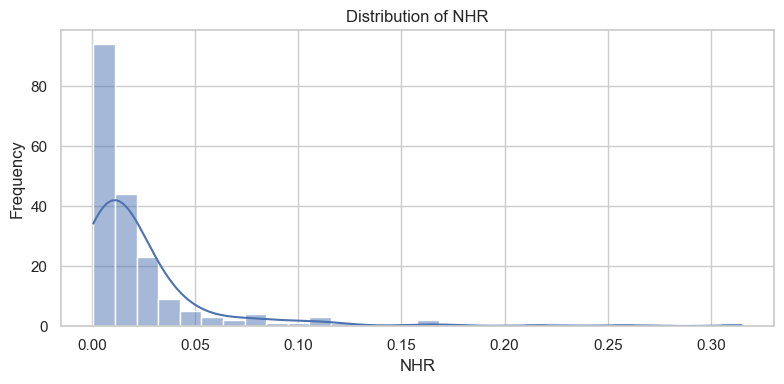

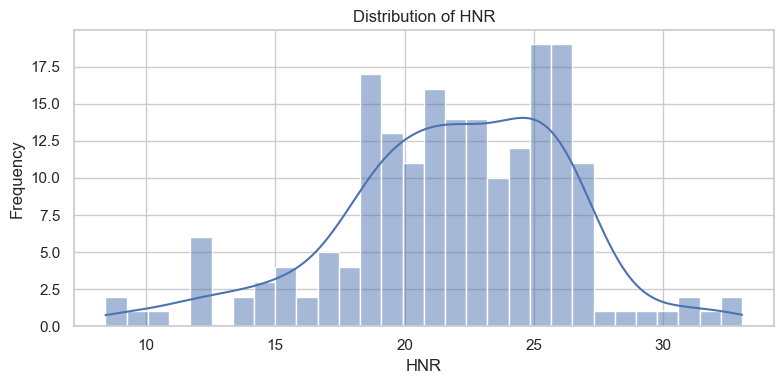

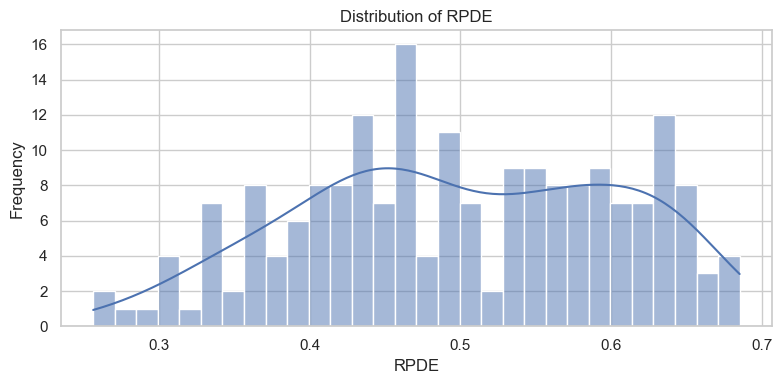

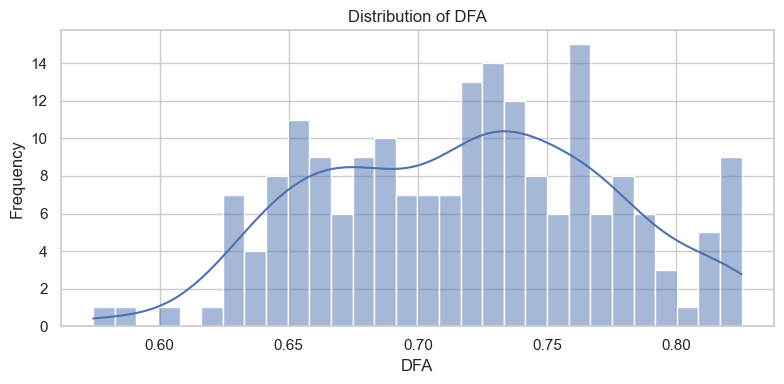

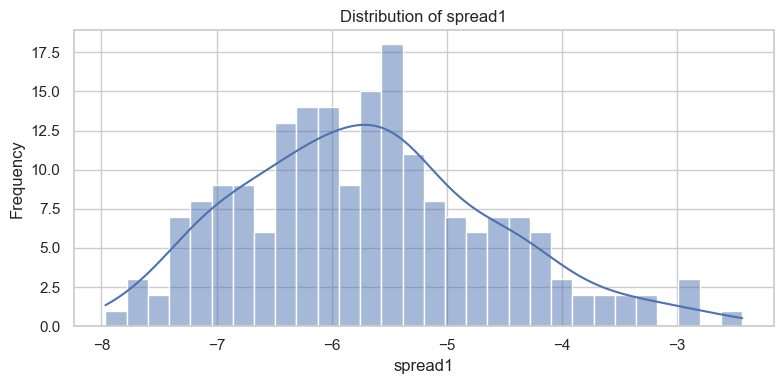

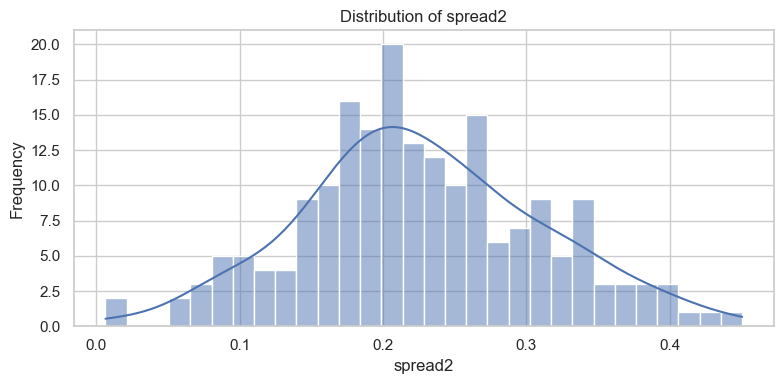

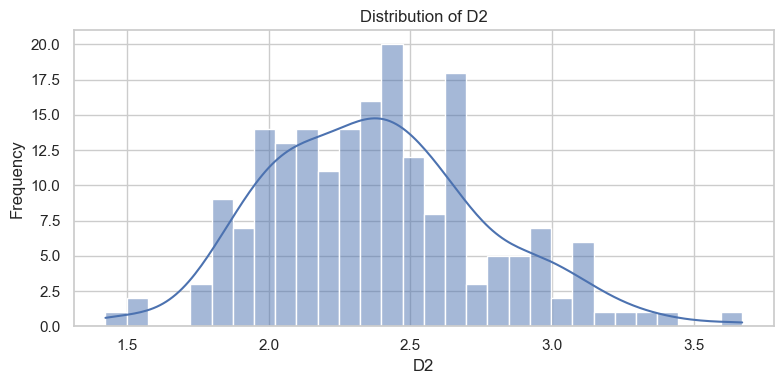

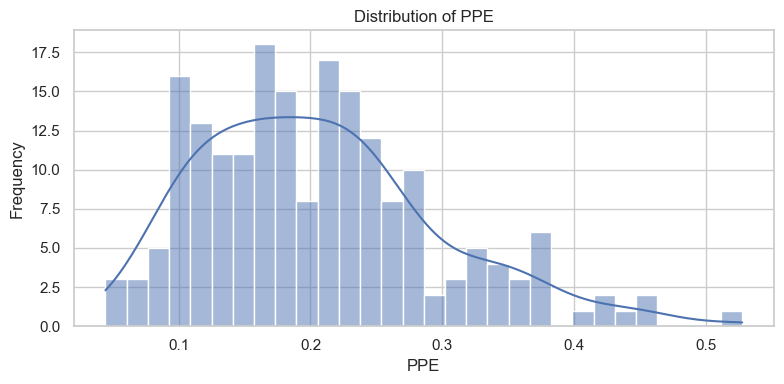

In [8]:
df_features = df1.drop(['name', 'status'], axis=1)

# Set plot style
sns.set(style="whitegrid")

# Plot distribution for each feature
for col in df_features.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_features[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

#### Observations:
##### - Based on the above visualization below variables have right-skewed distribution 
######    ** MDVP:Fhi(Hz), MDVP:Flo(Hz), MDVP:Jitter(%), MDVP:Jitter(Abs), MDVP:RAP, MDVP:PPQ, Jitter:DDP, 
######    ** MDVP:Shimmer, MDVP:Shimmer(dB), Shimmer:APQ3, Shimmer:APQ5, MDVP:APQ, Shimmer:DDA, NHR

##### - Visualization of below variables is close to bimodal distribution 
######   ** HNR, RPDE, DFA, D2  

##### - Visualization of below variables is close to normal distribution 
######   ** spread1, PPE,spread2 

### Q6. Check for outliers in the data. Are there any variables with high amount of outliers.

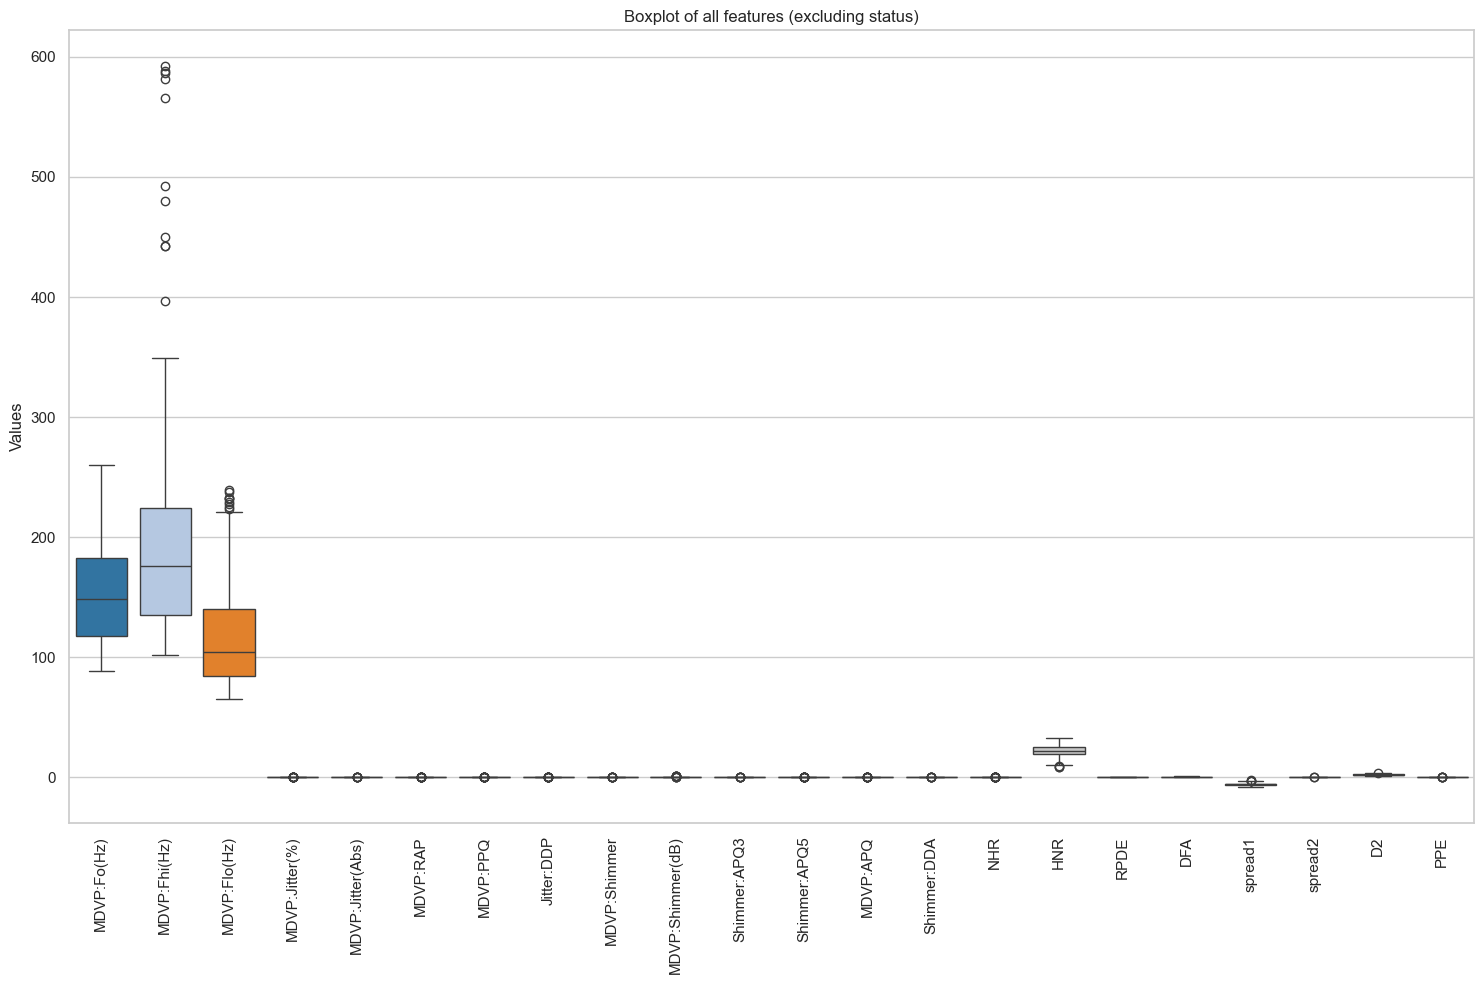

In [9]:
df_features = df1.drop(columns=['status', 'name'], errors='ignore')

sns.set(style="whitegrid")

# Plot boxplots
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_features, palette='tab20')
plt.title('Boxplot of all features (excluding status)')
plt.ylabel('Values')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Observations: 
##### As per above boxplot, variables MDVP:Fo(Hz) and MDVP:Fhi(Hz) have high amount of outliers.

### Q7. Are there any strong correlations among the independent features?

Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


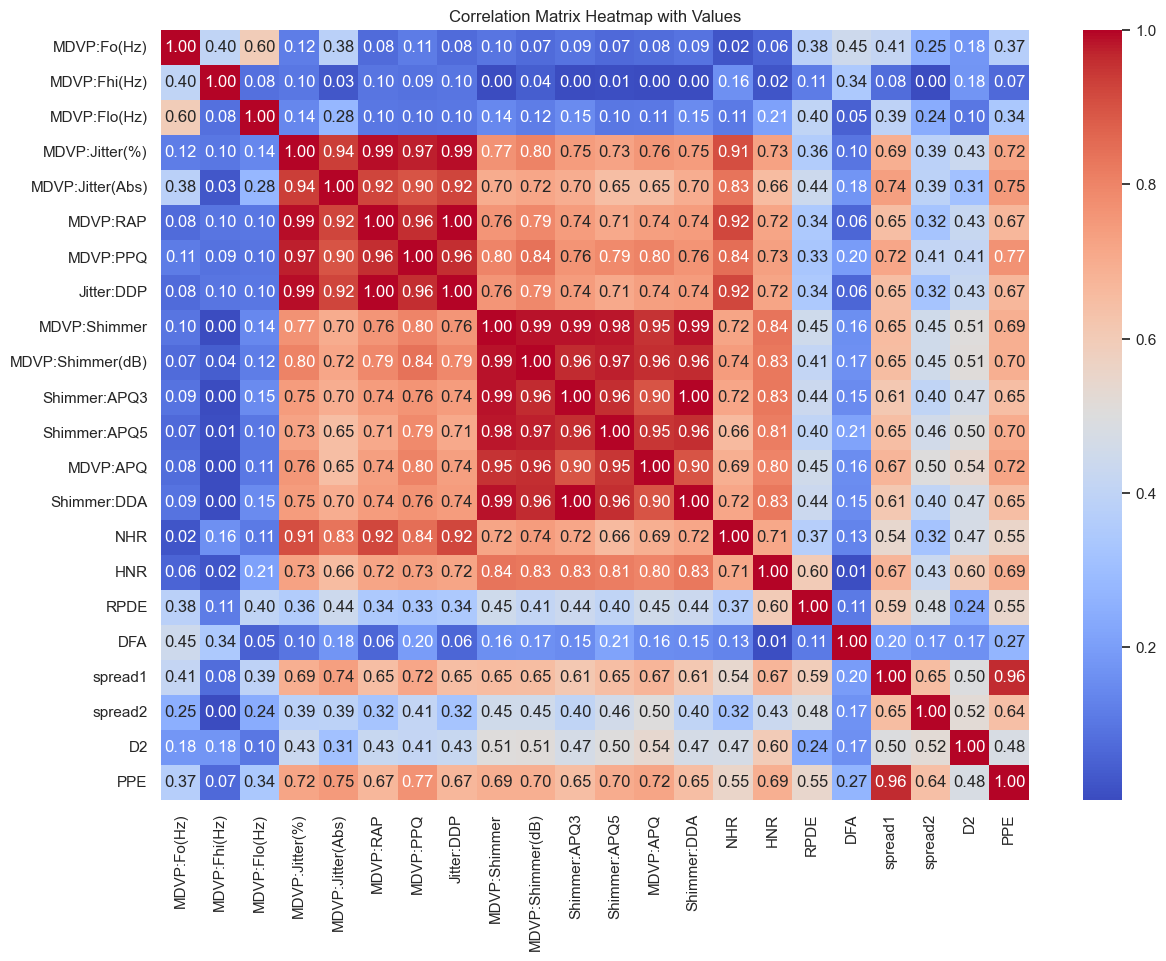

In [10]:
df_features = df1.drop(columns=['status', 'name'], errors='ignore')

# Compute correlation matrix
corr_matrix = df_features.corr().abs()

# Filter the upper triangle of the correlation matrix
upper_tri = corr_matrix.where(
    ~pd.DataFrame(np.tril(np.ones(corr_matrix.shape), k=0), dtype=bool)
)

# Find strongly correlated feature pairs (correlation > 0.8)
strong_corr = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={0: 'Correlation', 'level_0': 'Feature 1', 'level_1': 'Feature 2'})
)

strong_corr = strong_corr[strong_corr['Correlation'] > 0.8]

# Print strongly correlated pairs
print(strong_corr)

# Optional: Heatmap of the correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Correlation Matrix Heatmap with Values')
plt.show()

#### Observations:
##### If the correlation value in the heatmap is above 0.8, then we can consider it a strong correlation. Below variables have strong correlation:
###### - MDVP:Jitter(Abs) and MDVP:Jitter(%) with correaltion value as 0.94


###### - MDVP:RAP and MDVP:Jitter(%) with correaltion value as 0.99
###### - MDVP:RAP and MDVP:Jitter(Abs) with correaltion value as 0.92

###### -  MDVP:Shimmer(dB) and MDVP:Shimmer with correlation value as 0.99


###### - Shimmer:APQ3 and MDVP:Shimmer with correlation value as 0.99
###### - Shimmer:APQ3 and MDVP:Shimmer(dB) with correlation value as 0.96

###### - Shimmer:APQ5 and MDVP:Shimmer with correlation value as 0.98
###### - Shimmer:APQ5 and MDVP:Shimmer(dB) with correlation value as 0.97
###### - Shimmer:APQ5 and Shimmer:APQ3 with correlation value as 0.96


###### - Shimmer:DDA and MDVP:Shimmer with correlation value as 0.99
###### - Shimmer:DDA and MDVP:Shimmer(dB) with correlation value as 0.96
###### - Shimmer:DDA and Shimmer:APQ3 with correlation value as 1.0
###### - Shimmer:DDA and Shimmer:APQ5 with correlation value as 0.96
###### - Shimmer:DDA and MDVP:APQ  with correlation value as 0.90

###### - MDVP:APQ and MDVP:Jitter(%) with correaltion value as 0.97
###### - MDVP:APQ and MDVP:Jitter(Abs) with correaltion value as 0.90
###### - MDVP:APQ and MDVP:RAP with correaltion value as 0.96

###### - Jitter:DDP and MDVP:Jitter(%) with correlation value as 0.99 
###### - Jitter:DDP and MDVP:Jitter(Abs)  with correlation value as 0.92
###### - Jitter:DDP and MDVP:RAP with correlation value as 1.0
###### - Jitter:DDP and MDVP:PPQ with correlation value as 0.96

###### - NHR and MDVP:Jitter(%) with correaltion value as 0.91
###### - NHR and MDVP:Jitter(Abs) with correaltion value as 0.83
###### - NHR and MDVP:RAP with correaltion value as 0.92
###### - NHR and MDVP:PPQ with correaltion value as 0.84
###### - NHR and Jitter:DDP with correaltion value as 0.92

###### - HNR and MDVP:Shimmer with correlation value as 0.84
###### - HNR and MDVP:Shimmer(dB) with correlation value as 0.83
###### - HNR and Shimmer:APQ3 with correlation value as 0.83
###### - HNR and Shimmer:APQ5 with correlation value as 0.81
###### - HNR and Shimmer:DDA with correlation value as 0.83


###### - spread1 and PPE with correlation value as 0.96

### Q8. Split dataset into training & test dataset  

In [11]:
# Splitting Featues & Target
X = df_features
y = df1['status']

# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=10)

### Q9. Create a default decision tree model using criterion = Entropy 

In [12]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='entropy', random_state=10)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

In [13]:
# Evaluation of Model
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy of the Decision Tree model:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy of the Decision Tree model: 0.9743589743589743

Classification Report:
               precision    recall  f1-score   support

          No       0.92      1.00      0.96        11
         Yes       1.00      0.96      0.98        28

    accuracy                           0.97        39
   macro avg       0.96      0.98      0.97        39
weighted avg       0.98      0.97      0.97        39



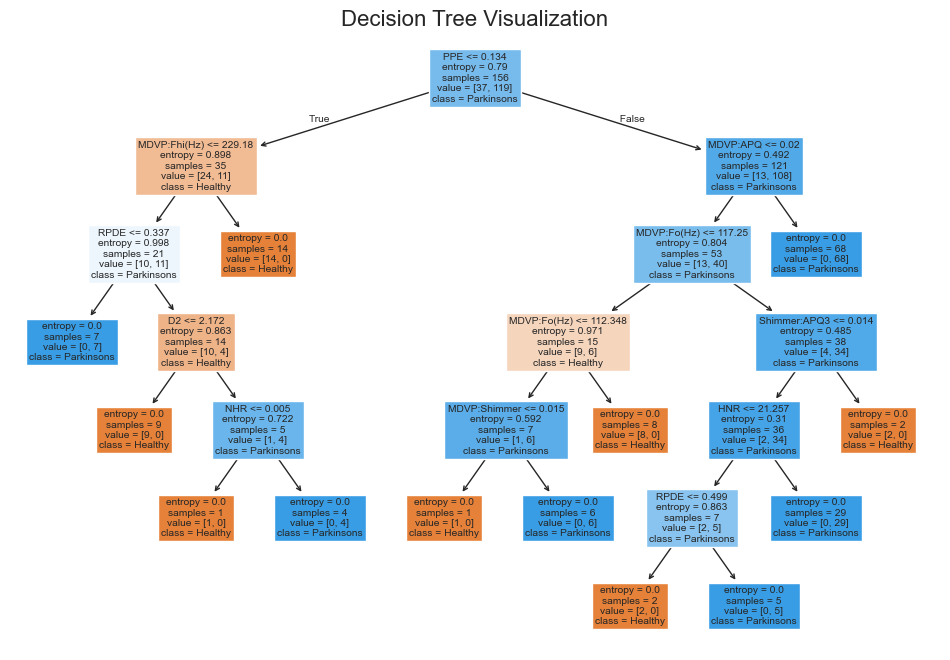

In [14]:
# Visualizing the Decision Tree
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plt.title("Decision Tree")
plot_tree(model, feature_names=X.columns, class_names=['Healthy', 'Parkinsons'], filled=True)
plt.title('Decision Tree Visualization', fontsize=16)
plt.show()

### Q10.  Use regularization parameters of max_depth, min_sample_leaf to recreate the model. What is the impact on the model accuracy? How does regularization help? 

In [15]:
# Create a model with regularization parameters
model = DecisionTreeClassifier(criterion='entropy',
                               max_depth=3,                      # Restrict the maximum depth of the tree
                               min_samples_leaf=5,               # Minimum samples per leaf node
                               random_state=10)                  # Set random seed for reproducibility

# Train the model again
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)


In [16]:
# Evaluation of Model post Hyperparameter Tunning
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy of the Decision Tree model post Hyperparameter Tunning:", accuracy)
print("\nClassification Report post Hyperparameter Tunning:\n", classification_report(y_test, y_pred))


Accuracy of the Decision Tree model post Hyperparameter Tunning: 0.8974358974358975

Classification Report post Hyperparameter Tunning:
               precision    recall  f1-score   support

          No       0.73      1.00      0.85        11
         Yes       1.00      0.86      0.92        28

    accuracy                           0.90        39
   macro avg       0.87      0.93      0.88        39
weighted avg       0.92      0.90      0.90        39



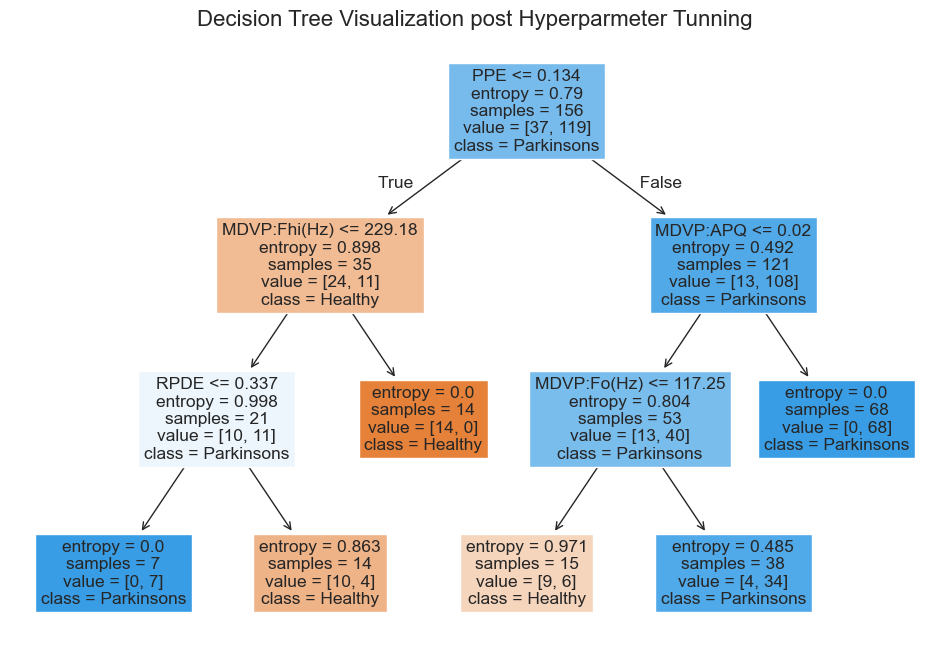

In [17]:
# Visualizing the Decision Tree post Hyperparameter Tunning
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=X.columns, class_names=['Healthy', 'Parkinsons'], filled=True)
plt.title('Decision Tree Visualization post Hyperparmeter Tunning', fontsize=16)
plt.show()

#### Observations: 
##### The model accuracy came down from Baseline Accuracy (97%) vs. Generalization Accuracy (89%).
##### The initial accuracy of 97% could indicate overfitting. A slight drop in accuracy after tuning might still suggest a better-generalized model, depending on the test-data performance.

### Q11. Implement a Random Forest model. What is the optimal number of trees that gives the best result?

Optimal number of trees: 30
Maximum accuracy: 1.00


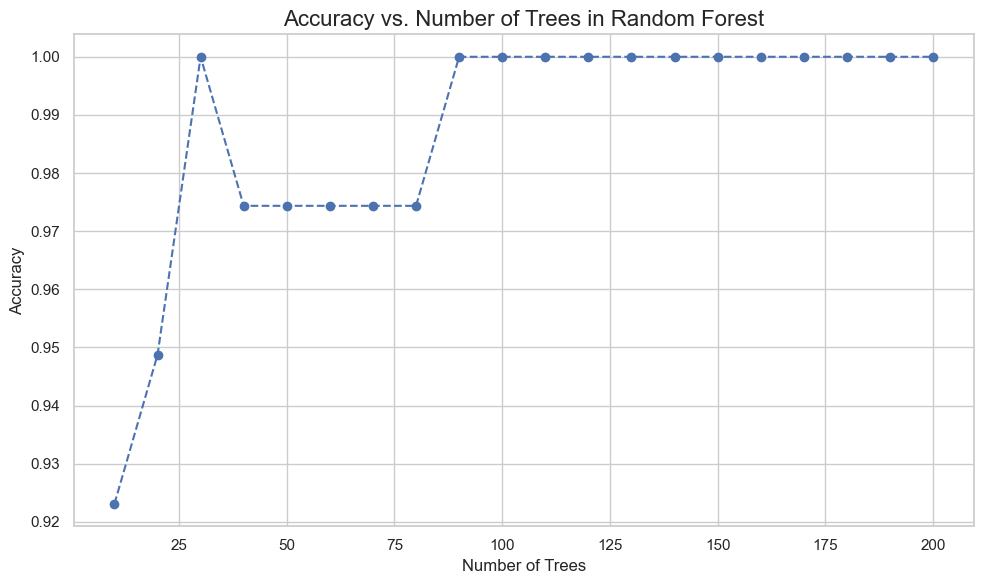

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter Tuning for n_estimators
n_estimators_range = range(10, 201, 10)  # Test different numbers of trees from 10 to 200
accuracy_scores = []

for n in n_estimators_range:
    # Initialize Random Forest with n trees
    rf_model = RandomForestClassifier(n_estimators=n, random_state=42)
    
    # Train the model
    rf_model.fit(X_train, y_train)
    
    # Test the model
    y_pred = rf_model.predict(X_test)
    
    # Calculate accuracy and store it
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append(acc)

# Identify the Optimal Number of Trees
optimal_trees = n_estimators_range[accuracy_scores.index(max(accuracy_scores))]
print(f'Optimal number of trees: {optimal_trees}')
print(f'Maximum accuracy: {max(accuracy_scores):.2f}')

# Plot Accuracy vs. Number of Trees
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, accuracy_scores, marker='o', linestyle='--', color='b')
plt.title('Accuracy vs. Number of Trees in Random Forest', fontsize=16)
plt.xlabel('Number of Trees', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

##                                                          CLUSTER ANALYSIS 

**The data definition is as follows:** <br>

**Region**:  City of the retailer

**Vegetables**: Annual spending on vegetables

**Personal_care**: Annual spending on personal care products

**Milk**: Annual spending on milk and milk products

**Grocery**: Annual spending on grocery

**Plasticware**: Annual spending on plasticware (container, bottles, dishes and so on)

In [19]:
#### Import the required libraries
# import 'Pandas' 
import pandas as pd 

# import 'Numpy' 
import numpy as np

# import subpackage of Matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# import 'Seaborn' 
import seaborn as sns

# to suppress warnings 
from warnings import filterwarnings
filterwarnings('ignore')
 
# import functions to perform scaling and normalization
from sklearn.preprocessing import MinMaxScaler

# import various functions from sklearn 
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans

<font color="#21618C">
                    <b>Load Dataset</b>

In [20]:
df2 = pd.read_csv("wholesale_cust.csv")

In [21]:
df2.head()

,Region,Vegetables,Personal_care,Milk,Grocery,Plasticware
0,Rochester,12667,2674,9656,7561,212
1,Rochester,7058,3293,9810,9568,1757
2,Rochester,6346,3516,8808,7684,2408
3,Rochester,13251,507,1196,4221,6407
4,Rochester,22620,1777,5410,7198,3908


In [22]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 444 entries, 0 to 443
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Region         444 non-null    object
 1   Vegetables     444 non-null    int64 
 2   Personal_care  444 non-null    int64 
 3   Milk           444 non-null    int64 
 4   Grocery        444 non-null    int64 
 5   Plasticware    444 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 20.9+ KB


In [23]:
df2.shape

(444, 6)

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>1. Is there any retailer whose entry is recorded more than once? If yes, do the needful.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [24]:
# Finding duplicate entries
duplicates = df2[df2.duplicated(keep=False)]

if duplicates.empty:
    print("No duplicate entries found")
else:
    print("Duplicate entries found")

Duplicate entries found


In [25]:
# Treating duplicate entries
df2_cleaned = df2.drop_duplicates(keep='first')

df2_cleaned.head()

,Region,Vegetables,Personal_care,Milk,Grocery,Plasticware
0,Rochester,12667,2674,9656,7561,212
1,Rochester,7058,3293,9810,9568,1757
2,Rochester,6346,3516,8808,7684,2408
3,Rochester,13251,507,1196,4221,6407
4,Rochester,22620,1777,5410,7198,3908


In [26]:
df2_cleaned.shape

(439, 6)

In [27]:
# Checking for duplicates again
print("Validating duplicate entries treatment...")
duplicates_after_cleaning = df2_cleaned[df2_cleaned.duplicated(keep=False)]

if duplicates_after_cleaning.empty:
    print("No duplicate entries found")
else:
    print("Duplicate entries found")

Validating duplicate entries treatment...
No duplicate entries found


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>2. Identify the different cities to which the retailers belong. Also, visualize their count in different cities.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [28]:
unique_city = df2_cleaned['Region'].unique()
print(unique_city)

['Rochester' 'Oneonta' 'Albany']


In [29]:
city_count = df2_cleaned['Region'].value_counts()
print(city_count)

Region
Rochester    315
Oneonta       77
Albany        47
Name: count, dtype: int64


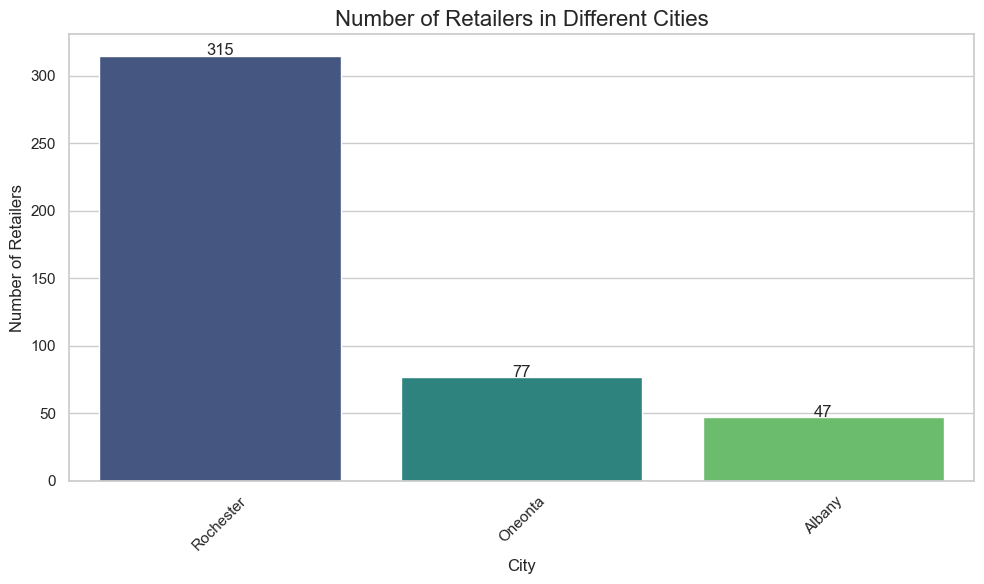

In [30]:
# Create bar plot
plt.figure(figsize=(10, 6))  # Set plot size
sns.barplot(x=city_count.index, y=city_count.values, palette="viridis")  # Bar chart

# Add bar values (numbers on top of bars)
for i, value in enumerate(city_count.values):
    plt.text(i, value + 0.1, str(value), ha='center', fontsize=12)

# Add titles and labels
plt.title("Number of Retailers in Different Cities", fontsize=16)
plt.xlabel("City", fontsize=12)
plt.ylabel("Number of Retailers", fontsize=12)

# Rotate x-axis labels for better readability (optional, depending on data)
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>3. Identify the extreme observations in the data using a visualization technique. </b>
                </font>
            </div>
        </td>
    </tr>
</table>

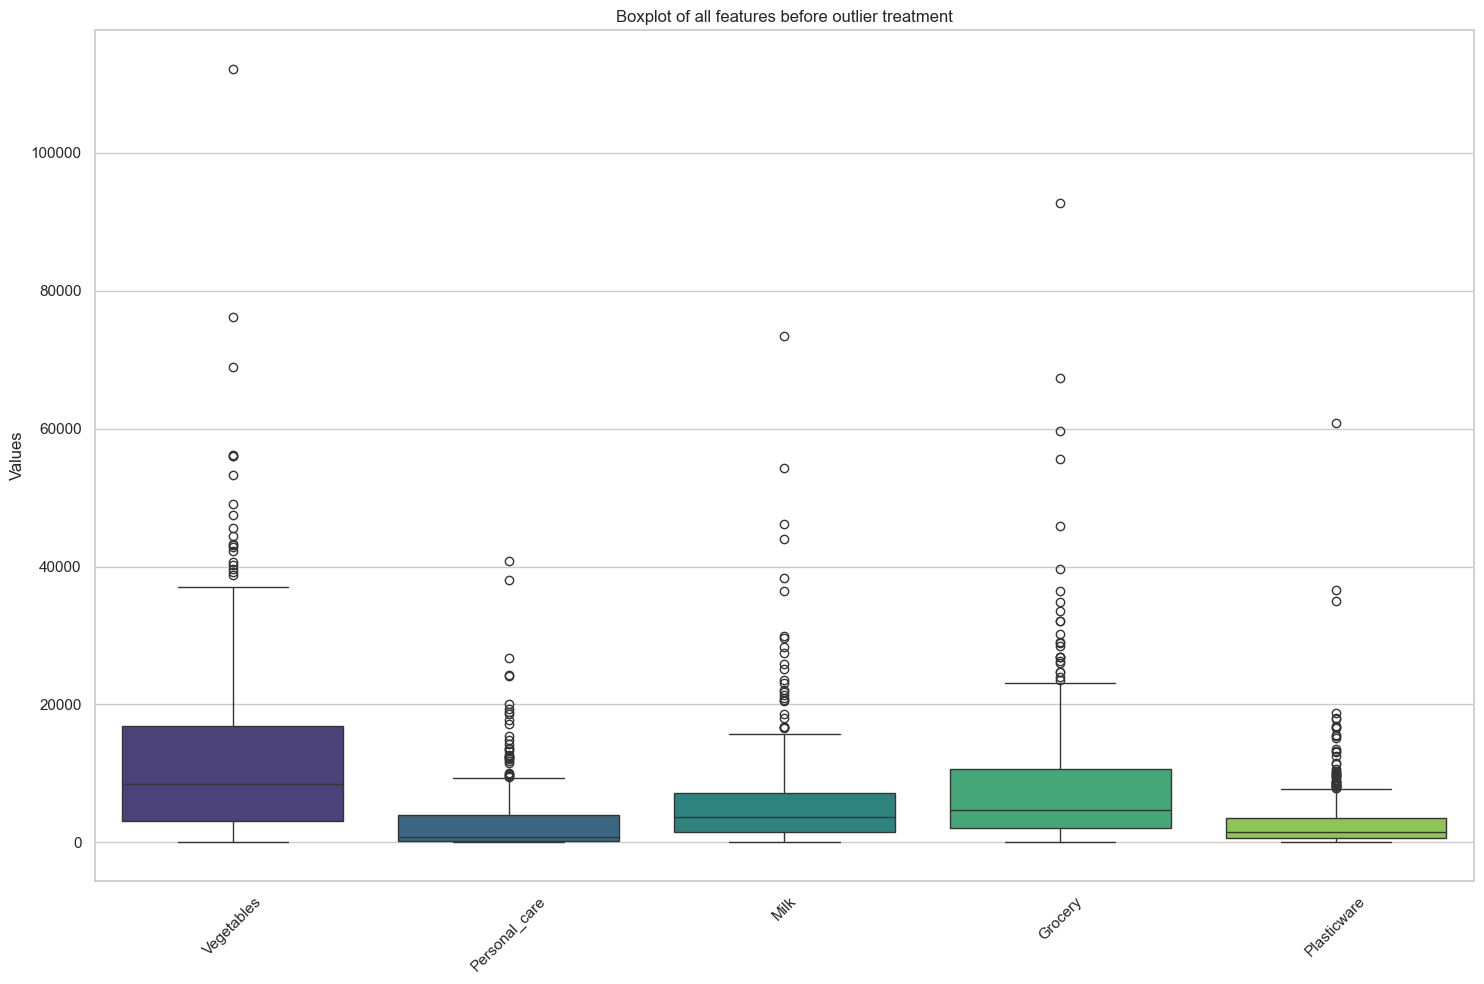

In [31]:
# Dropping Categorical variable
df_features = df2_cleaned.drop(columns=['Region'], errors='ignore')

sns.set(style="whitegrid")

# Plot boxplots
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_features, palette='viridis') 
plt.title('Boxplot of all features before outlier treatment')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Observations:
##### As per the above box plot all numerical variables have the outliers.

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>4. Use the appropriate technique to remove the observations greater than 3*IQR above the third quartile.
                    </b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [32]:
# Descriptive Statistics
df_features.describe().T

,count,mean,std,min,25%,50%,75%,max
Vegetables,439.0,11994.517084,12661.226942,3.0,3119.5,8475.0,16934.5,112151.0
Personal_care,439.0,2890.075171,4770.535549,3.0,260.0,821.0,3935.0,40827.0
Milk,439.0,5793.398633,7393.705668,3.0,1501.5,3634.0,7196.5,73498.0
Grocery,439.0,7923.369021,9532.051087,7.0,2137.0,4740.0,10694.5,92780.0
Plasticware,439.0,3047.179954,4867.584962,3.0,672.5,1496.0,3537.5,60870.0


In [33]:
# Outlier Treatment
def remove_outlier(col):
    Q1,Q3 = np.percentile(col,[25,75])
    IQR = Q3 - Q1
    lower_range = Q1 - (3 * IQR)
    upper_range = Q3 + (3 * IQR)
    print(f"Column: {col.name}, Lower: {lower_range}, Upper: {upper_range}") 
    return lower_range,upper_range

In [34]:
for column in df_features.columns:
        lr, ur = remove_outlier(df_features[column])
        df_features[column] = np.where(df_features[column] > ur, ur, df_features[column])
        df_features[column] = np.where(df_features[column] < lr, lr, df_features[column])

Column: Vegetables, Lower: -38325.5, Upper: 58379.5
Column: Personal_care, Lower: -10765.0, Upper: 14960.0
Column: Milk, Lower: -15583.5, Upper: 24281.5
Column: Grocery, Lower: -23535.5, Upper: 36367.0
Column: Plasticware, Lower: -7922.5, Upper: 12132.5


In [35]:
# Descriptive Statistics post outlier treatment 
df_features.describe().T

,count,mean,std,min,25%,50%,75%,max
Vegetables,439.0,11807.272210,11630.848812,3.0,3119.5,8475.0,16934.5,58379.5
Personal_care,439.0,2658.136674,3665.775578,3.0,260.0,821.0,3935.0,14960.0
Milk,439.0,5411.694761,5460.624421,3.0,1501.5,3634.0,7196.5,24281.5
Grocery,439.0,7598.343964,7776.129437,7.0,2137.0,4740.0,10694.5,36367.0
Plasticware,439.0,2724.690205,3042.771579,3.0,672.5,1496.0,3537.5,12132.5


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>5. Transform the numerical variables such that the values will be between 0 and 1.
                    </b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [36]:
# Scaling Numerical Values
from sklearn.preprocessing import MinMaxScaler

# Initialize and apply MinMaxScaler
scaler = MinMaxScaler()  # Create a scaler instance
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns)

# Print the scaled data
print("Normalized Data (Values Between 0 and 1):\n")
df_scaled.describe().T

Normalized Data (Values Between 0 and 1):



,count,mean,std,min,25%,50%,75%,max
Vegetables,439.0,0.202209,0.199239,0.0,0.053386,0.145127,0.290040,1.0
Personal_care,439.0,0.177518,0.245088,0.0,0.017183,0.054690,0.262887,1.0
Milk,439.0,0.222777,0.224916,0.0,0.061721,0.149556,0.296291,1.0
Grocery,439.0,0.208783,0.213865,0.0,0.058581,0.130171,0.293936,1.0
Plasticware,439.0,0.224386,0.250857,0.0,0.055196,0.123088,0.291397,1.0


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>6. Perform K-Means clustering with varying K from 2 to 4, and identify the optimal number of clusters using the Silhouette plot.
                    </b>
                </font>
            </div>
        </td>
    </tr>
</table>

For n_clusters = 2, the average silhouette_score is 0.43


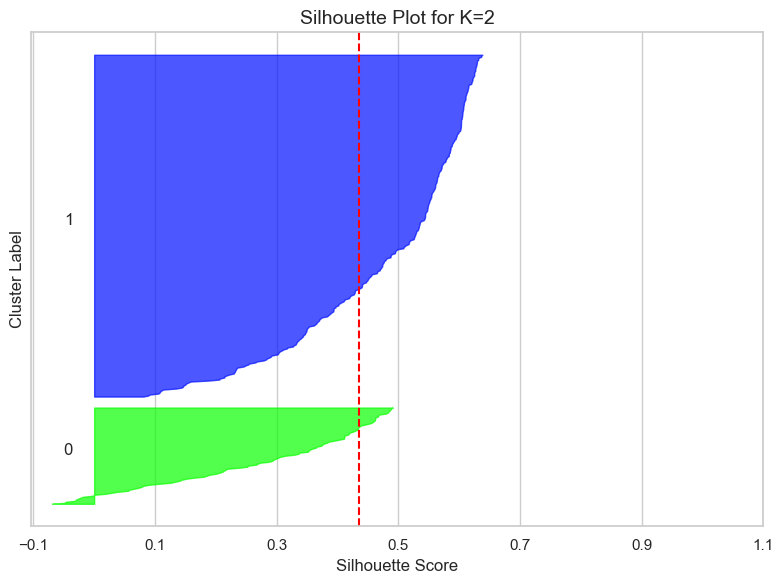

For n_clusters = 3, the average silhouette_score is 0.42


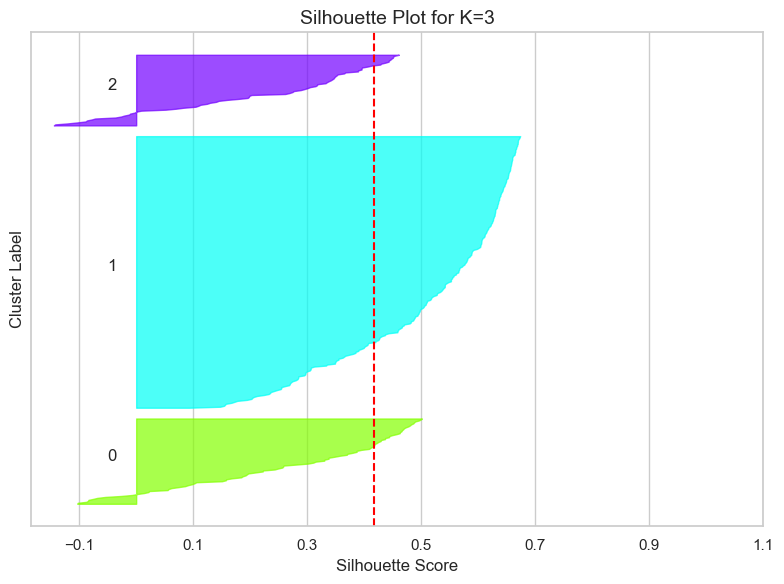

For n_clusters = 4, the average silhouette_score is 0.36


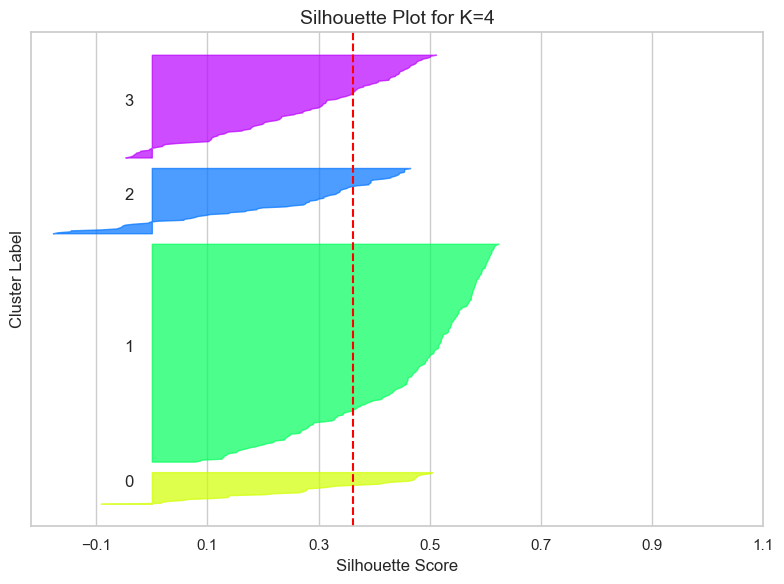

In [37]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Vary K from 2 to 4 and calculate Silhouette Scores
range_n_clusters = [2, 3, 4]

for n_clusters in range_n_clusters:
    # Initialize KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(df_scaled)

    # Calculate the average silhouette score for each cluster
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is {silhouette_avg:.2f}")
    
    # Generate Silhouette Plot
    sample_silhouette_values = silhouette_samples(df_scaled, cluster_labels)

    # Create a subplot for silhouette plots
    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(8, 6)

    y_lower = 10
    for i in range(n_clusters):
        # Silhouette scores for samples in cluster i
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = sns.color_palette("hsv", n_clusters)[i]
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10  # 10 for spacing between clusters

    ax.set_title(f"Silhouette Plot for K={n_clusters}", fontsize=14)
    ax.set_xlabel("Silhouette Score", fontsize=12)
    ax.set_ylabel("Cluster Label", fontsize=12)

    # Add a line for average silhouette score
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])  # Clear the y-axis labels/ticks
    ax.set_xticks(np.arange(-0.1, 1.1, 0.2))

    plt.tight_layout()
    plt.show()

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>7. Consider the numerical variables to create two clusters and visualize them using the variables 'Vegetables' and 'Personal_care'.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

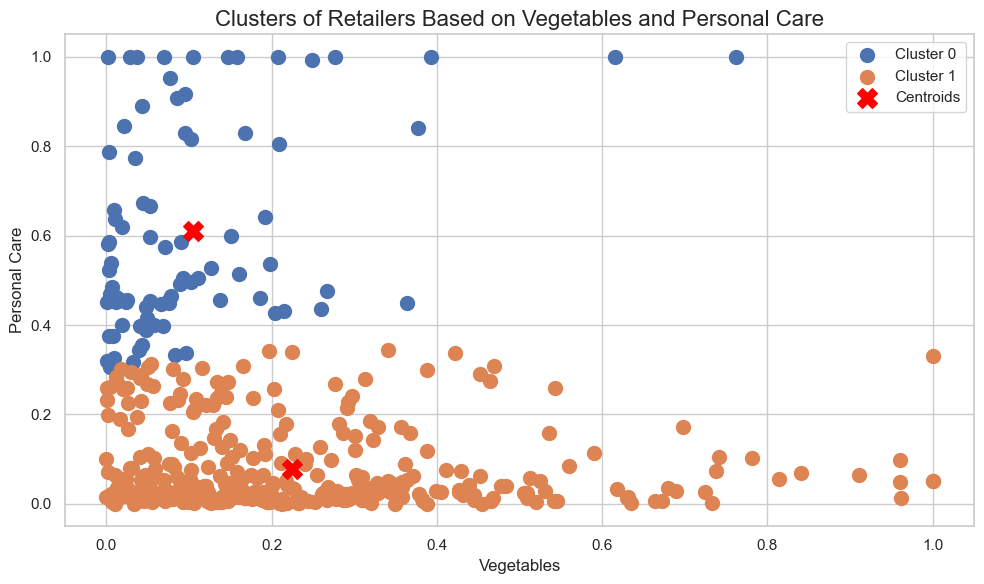

Dataset with Assigned Clusters:
     Vegetables  Personal_care      Milk   Grocery  Plasticware  Cluster
0      0.216937       0.178579  0.397595  0.207756     0.017231        1
1      0.120853       0.219964  0.403938  0.262954     0.144606        1
2      0.108657       0.234873  0.362667  0.211139     0.198277        1
3      0.226941       0.033697  0.049138  0.115897     0.527969        1
4      0.387433       0.118607  0.222707  0.197772     0.321942        1
..          ...            ...       ...       ...          ...      ...
434    0.508766       0.011968  0.496242  0.440594     1.000000        1
435    0.671931       0.006017  0.058817  0.020820     0.371079        1
436    0.248867       0.992044  0.637807  0.831573     0.035451        0
437    0.176218       0.011032  0.081471  0.061194     0.084917        1
438    0.047690       0.031691  0.069815  0.068564     0.004947        1

[439 rows x 6 columns]


In [38]:
# Select only 'Vegetables' and 'Personal_care' for visualization
selected_features = ['Vegetables', 'Personal_care']
df_subset = df_scaled[selected_features]

# Normalize the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_subset)  # Normalize only Vegetables and Personal_care

# Apply K-Means clustering with K=2
kmeans = KMeans(n_clusters=2, random_state=42)  # K=2 clusters
df_scaled['Cluster'] = kmeans.fit_predict(scaled_data)  # Assign cluster labels

# Visualize Clusters using 'Vegetables' and 'Personal_care'
plt.figure(figsize=(10, 6))
for cluster in np.unique(df_scaled['Cluster']):
    subset = df_scaled[df_scaled['Cluster'] == cluster]
    plt.scatter(
        subset['Vegetables'], 
        subset['Personal_care'], 
        label=f"Cluster {cluster}", 
        s=100  # Marker size
    )

# Add centroids
# Extract scaled centroids for Vegetables and Personal_care (only these two variables)
centroids = kmeans.cluster_centers_
# Scale centroids back to original values
centroids_original_scale = scaler.inverse_transform(centroids)  # Only for Vegetables and Personal_care
plt.scatter(
    centroids_original_scale[:, 0], 
    centroids_original_scale[:, 1], 
    s=200, 
    c='red', 
    marker='X', 
    label='Centroids'
)

# Add labels, title, and legend
plt.title('Clusters of Retailers Based on Vegetables and Personal Care', fontsize=16)
plt.xlabel('Vegetables', fontsize=12)
plt.ylabel('Personal Care', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Display the dataset with clusters
print("Dataset with Assigned Clusters:")
print(df_scaled)

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>8. Draw insights from the clusters formed in the previous question with respect to each variable in the data.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [39]:

# Group data by clusters and calculate the mean for each variable
cluster_summary = df_scaled.groupby('Cluster').mean()

# Optionally display additional statistics (e.g., standard deviation) for deeper analysis
cluster_sd = df_scaled.groupby('Cluster').std()

# Print out insights
print("Cluster-wise Means:")
print(cluster_summary)

print("\nCluster-wise Standard Deviations:")
print(cluster_sd)

Cluster-wise Means:
         Vegetables  Personal_care      Milk   Grocery  Plasticware
Cluster                                                            
0          0.104516       0.609209  0.481118  0.538744     0.121982
1          0.224986       0.076871  0.162546  0.131854     0.248261

Cluster-wise Standard Deviations:
         Vegetables  Personal_care      Milk   Grocery  Plasticware
Cluster                                                            
0          0.130184       0.229280  0.262868  0.229322     0.121915
1          0.205696       0.090775  0.164960  0.113555     0.266806


#### Observations:

##### <b> Cluster-Wise Analysis and Insights: </b>


##### <b> Cluster 0 </b>
##### Characterization: Cluster 0 represents customers with high demand for Personal Care, Milk, and Grocery products, but low demand for Vegetables and Plasticware.

##### <b> Cluster 1 </b>
##### Characterization: Cluster 1 represents customers with high demand for Plasticware and Vegetables, but low demand for Personal Care, Milk, and Grocery products.

##### Behavior-Based Recommendations:

##### <b> For Cluster 0 (General Grocery Buyers): </b>
##### - Focus on ensuring availability of personal care, milk, and grocery products, as these are the primary needs of this cluster.
##### - Offer variety and competitive pricing for these items to increase loyalty and sales volume.
##### - Provide combo deals or discounted bundles specifically for products like Milk and Groceries.


##### <b> For Cluster 1 (Niche/Specific Buyers): </b>
##### - Focus on plasticware and vegetables as core products.
##### - Plasticware items like food containers, disposable cutlery, and bulk packaging will appeal strongly to customers.
##### - For vegetables, freshness and quality are likely to be key drivers. 
#####  - Ensure that vegetable supply remains consistent, with seasonal produce to adapt to changing needs.


##### <b> Conclusion: </b>
##### Based on the cluster analysis:

##### <b> Cluster 0: </b>
##### ** Represents general grocery demand: Includes daily essentials (Milk, Groceries), with a strong gap for Personal Care products.
##### ** Businesses in this cluster are most likely retail grocery stores serving households and communities with frequent, versatile product demand.

##### <b> Cluster 1: </b>
##### ** Represents niche wholesale buyers: Likely serving industries (e.g., catering) or farms with a focus on Plasticware and Vegetables.
##### ** They exhibit a focused purchasing pattern and limited interest in general staples, indicating specialization or reduced scale of operations.

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>9. Group the retailers from Oneonta into 1 to 5 clusters and find the optimal number of clusters using within cluster sum of squares.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

Optimal number of clusters: 2


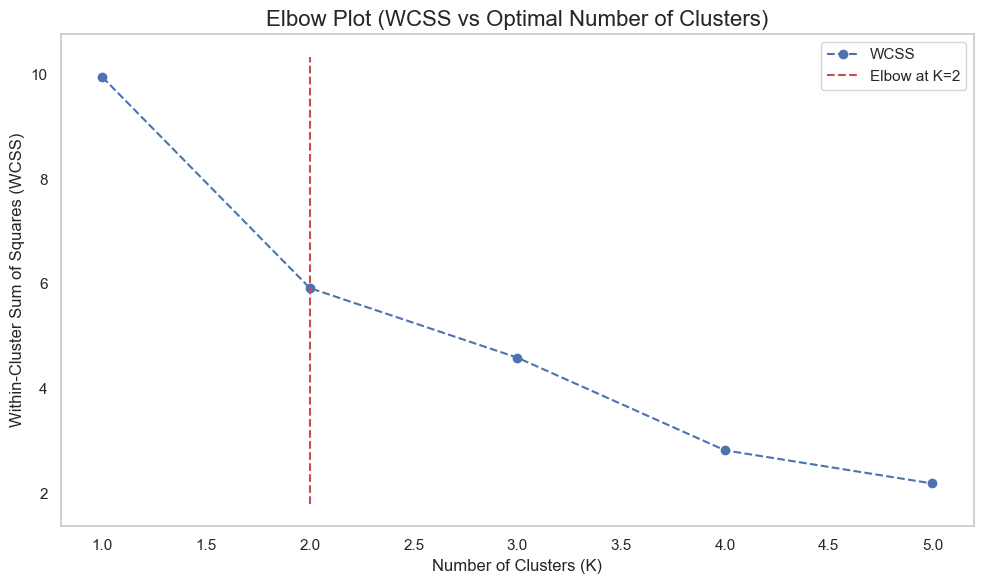

In [40]:
# Using the dataframe which has region
df = df2_cleaned

# Filter data to include only Oneonta
oneonta_data = df[df['Region'] == 'Oneonta']

# Select numerical columns for clustering
features = oneonta_data[['Vegetables', 'Personal_care', 'Milk']]

# Normalize the data (Min-Max Scaling)
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

# Apply K-Means and calculate WCSS for K=1 to K=5
wcss = []
cluster_range = range(1, 6)  

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)  # Initialize K-Means
    kmeans.fit(scaled_features)                    # Fit the model
    wcss.append(kmeans.inertia_)                   # Append WCSS (inertia)

from kneed import KneeLocator

# Detect the elbow point
knee_locator = KneeLocator(cluster_range, wcss, curve="convex", direction="decreasing")
optimal_k = knee_locator.knee  # Optimal number of clusters

print(f"Optimal number of clusters: {optimal_k}")

# Plot the Elbow Plot (WCSS vs. Number of Clusters)
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, wcss, marker='o', linestyle='--', color='b', label='WCSS')
plt.vlines(optimal_k, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='r', label=f'Elbow at K={optimal_k}')
plt.title('Elbow Plot (WCSS vs Optimal Number of Clusters)', fontsize=16)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>10. Group the retailers from Oneonta into the optimal number of clusters obtained in Q9. Also, find the number of retailers in each cluster.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [41]:
# Apply K-Means Clustering with the Optimal Number of Clusters
optimal_k = 2  # Replace this with the optimal K value from the Elbow Method
kmeans = KMeans(n_clusters=optimal_k, random_state=42)  # Initialize KMeans
cluster_labels = kmeans.fit_predict(scaled_features)  # Fit and predict the clusters

# Add Cluster Labels to the Data
oneonta_data['Cluster'] = cluster_labels

# Count Retailers in Each Cluster
cluster_counts = oneonta_data['Cluster'].value_counts()
print("\nNumber of Retailers in Each Cluster:")
print(cluster_counts)

# Print the dataset with assigned clusters
print("\nOneonta Retailers with Cluster Labels:")
print(oneonta_data)



Number of Retailers in Each Cluster:
Cluster
0    68
1     9
Name: count, dtype: int64

Oneonta Retailers with Cluster Labels:
      Region  Vegetables  Personal_care   Milk  Grocery  Plasticware  Cluster
196  Oneonta       30624            763   7209     4897        18713        0
197  Oneonta        2427           4314   7097    10391         1125        0
198  Oneonta       11686            592   2154     6824         3531        0
199  Oneonta        9670            402   2280     2112          520        0
200  Oneonta        3067           9959  13240    23127         3946        1
..       ...         ...            ...    ...      ...          ...      ...
269  Oneonta       11908           6374   8053    19847         1064        0
270  Oneonta       15218            333    258     1138         2518        0
271  Oneonta        4720            197   1032      975         5498        0
272  Oneonta        2083            147   5007     1563         1113        0
273  Oneonta  